- Автор: Сереженко Елена

### Содержание проекта
* [1. Проверка гипотезы в Python и составление аналитической записки](#1.-Проверка-гипотезы-в-Python-и-составление_аналитической-записки)
    * [1.1. Цели и задачи 1 части](#1.1.-Цели-и-задачи-1-части)
    * [1.2. Описание данных](#1.2.-Описание-данных)
    * [1.3. Загрузка данных и знакомство с ними](#1.3.-Загрузка-данных-и-знакомство-с-ними)
    * [1.4. Поиск дубликатов](#1.4.-Поиск-дубликатов)
    * [1.5. Подготовка данных для проверки гипотезы](*1.5.-Подготовка-данных-для-проверки-гипотезы)
    * [1.6. Проверка гипотезы в Python](*1.6.-Проверка-гипотезы-в-Python)
    * [1.7. Аналитическая записка](*1.7.-Аналитическа-записка)
* [2. Анализ результатов A/B-тестирования](*2.-Анализ-результатов-A/B-тестирования)
    * [2.1. Цели и задачи 2 части](#2.1.-Цели-и-задачи-2-части)
    * [2.2. Описание данных](#2.2.-Описание-данных)
    * [2.3. Загрузка данных](*2.3.-Загрузка-данных)
    * [2.4. По таблице `ab_test_participants` оценить корректность проведения теста](*2.4.-По-таблице-`ab_test_participants`-оценить-корректность-проведения-теста)
        * [2.4.1. Пользователи, участвующие в тесте](*2.4.1.-Пользователи,-участвующие-в-тесте)
        * [2.4.2. Анализ пользовательской активности по таблице `ab_test_events`](*2.4.2-Анализ-пользовательской-активности-по-таблице-`ab_test_events`)
    * [2.5. Оценка результатов A/B-тестирования](*2.5.-Оценка-результатов-A/B-тестирования)

# 1. Проверка гипотезы в Python и составление аналитической записки

## 1.1. Цели и задачи 1 части
Основная цель данной части: проверить, проводят ли пользователи из Санкт‑Петербурга в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

Задачи:
- загрузить и предобработать данные (проверка дубликатов, анализ распределения);
- провести проверку гипотезы в Python;
- описать результаты и сформулировать выводы в аналитической записке.

## 1.2. Описание данных
`yandex_knigi_data.csv` - таблица с историческими данными пользователей из Москвы и Санкт-Петербурга c суммой часов их активности. Путь к файлу: `/datasets/yandex_knigi_data.csv`. Данные представлены за период с 1 сентября по 11 декабря 2024 года.

Поля таблицы:
- `puid` — идентификатор пользователя;
- `hours` — длительность чтения или прослушивания в часах;
- `city` — город.

## 1.3. Загрузка данных и знакомство с ними
Импортируем библиотеку `pandas`. 
Дополнительно импортируем библиотеки, необходимые для дальнейшей работы.

Загружаем данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import seaborn as sns
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

Для удобства удалим первый столбец `Unnamed`, добавив параметр index_col=0, так как он дублирует индексы.

In [2]:
yandex_knigi_data=pd.read_csv('https://code.s3.yandex.net//datasets/yandex_knigi_data.csv',index_col=0)

yandex_knigi_data.info()
yandex_knigi_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


Количество заполненных строк везде совпадает(8784).

Типы данных соответствуют информации в стобцах.    

## 1.4. Поиск дубликатов
Для начала проверим на явные дубликаты датасет `yandex_knigi_data`.

In [3]:
yandex_knigi_data.duplicated().sum()

np.int64(0)

Посчитаем количество уникальных пользователей.

In [4]:
puid_count = yandex_knigi_data['puid'].nunique()

puid_count

8540

Количество строк в таблице - 8784, а количество уникальных пользователей - 8540.
Значит есть неявные дубликаты - 244.

In [5]:
yandex_knigi_data.duplicated(subset='puid').sum()

np.int64(244)

Возможно, одни и те же пользователи присутствуют в обоих городах. Выведем некоторые значения для наглядности. Если это так, то можно будет удалить эти дубликаты.

In [6]:
duplicates=yandex_knigi_data[yandex_knigi_data.duplicated(subset=['puid'])]['puid'].to_list()

yandex_knigi_data[yandex_knigi_data['puid'].isin(duplicates)].sort_values(by='puid').head(8)

,city,puid,hours
35,Москва,2637041,10.317371
6247,Санкт-Петербург,2637041,3.883926
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
6279,Санкт-Петербург,10597984,9.041320
150,Москва,10815097,9.086655
6283,Санкт-Петербург,10815097,0.323291


In [7]:
yandex_knigi_data_clear=yandex_knigi_data.drop_duplicates(subset='puid', keep='first')

yandex_knigi_data_clear.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8540 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8540 non-null   object 
 1   puid    8540 non-null   int64  
 2   hours   8540 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 266.9+ KB


## 1.5. Подготовка данных для проверки гипотезы
Проверим количество пользователей по группам в абсолютном и относительном значениях.

In [8]:
users_group=yandex_knigi_data_clear['city'].value_counts()
users_group_ratio=yandex_knigi_data_clear['city'].value_counts(normalize=True)

print(users_group)
print(users_group_ratio)

city
Москва             6234
Санкт-Петербург    2306
Name: count, dtype: int64
city
Москва             0.729977
Санкт-Петербург    0.270023
Name: proportion, dtype: float64


Дополнительно проверим: есть ли участники теста, которые встречаются в обеих группах.

In [9]:
group_msk=set(yandex_knigi_data_clear[yandex_knigi_data_clear['city']=='Москва']['puid'].unique())
group_spb=set(yandex_knigi_data_clear[yandex_knigi_data_clear['city']=='Санкт-Петербург']['puid'].unique())
users_msk_spb=group_msk.intersection(group_spb)

if len(users_msk_spb)==0:
    print('Нет участников, которые встречаются в обеих группах') 
else:
    print(f'Количество участников в обеих группах: {len(users_msk_spb)}')

Нет участников, которые встречаются в обеих группах


Посчитаем процентную разницу между группами.

In [10]:
diff_msk_spb=round(100*abs(users_group['Москва'] - users_group['Санкт-Петербург'])/users_group['Москва'],2)

diff_msk_spb

np.float64(63.01)

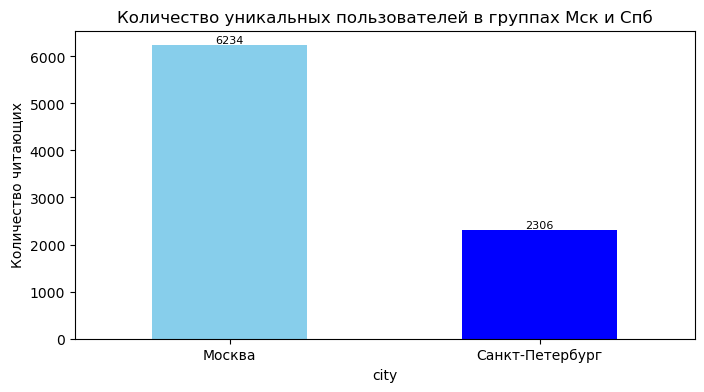

In [11]:
colors=['skyblue', 'blue']
ax=users_group.plot(
    kind='bar',
    title='Количество уникальных пользователей в группах Мск и Спб',
    figsize=(8, 4),
    rot=0,
    ylabel='Количество читающих',
    color=colors
)

for i, v in enumerate(users_group):
    ax.text(i, v+10, str(v), ha='center', va='bottom', fontsize=8)

Неравенство групп по географии — серьёзный источник смещения. Пользователей из Москвы почти в 3 раза больше, чем пользователей из Санкт-Петербурга. Такая разница может исказить результаты тестов.

Построим гистограммы по городам

In [12]:
msk_hours=yandex_knigi_data_clear[yandex_knigi_data_clear['city']=='Москва']['hours']
spb_hours=yandex_knigi_data_clear[yandex_knigi_data_clear['city']=='Санкт-Петербург']['hours']

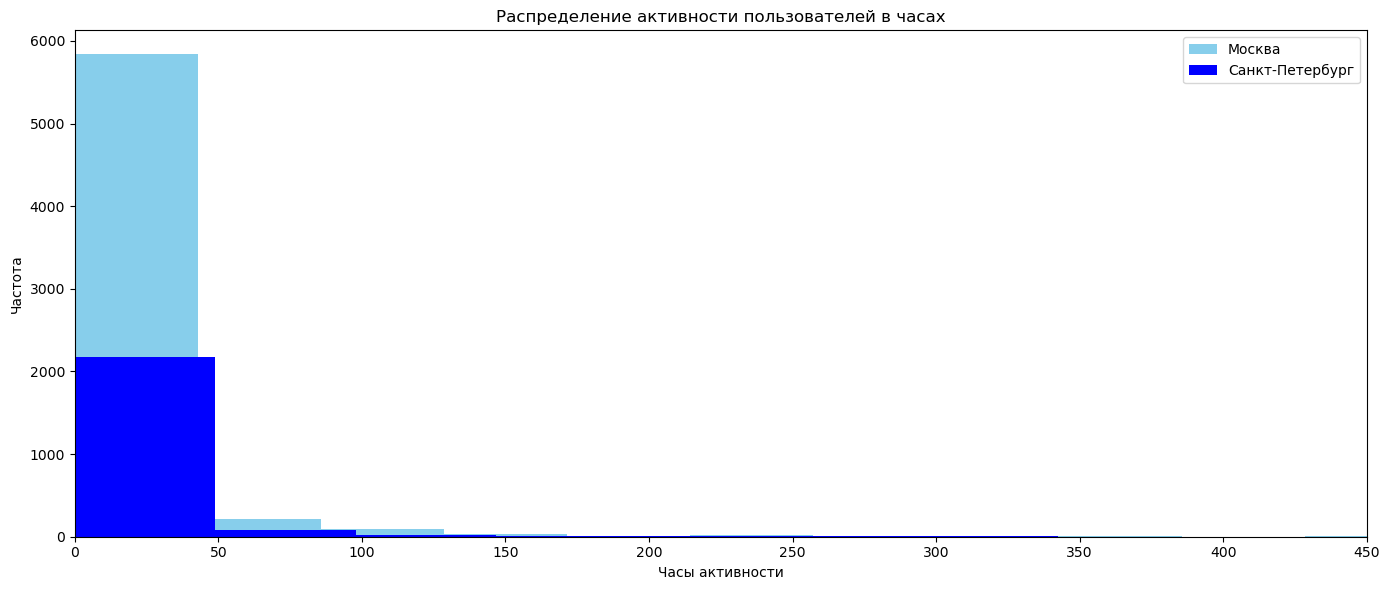

In [13]:
colors = ['skyblue', 'blue']

plt.figure(figsize=(14, 6))
plt.hist(msk_hours, bins=20, color=colors[0], label='Москва')
plt.hist(spb_hours, bins=20, color=colors[1], label='Санкт-Петербург')
plt.title('Распределение активности пользователей в часах')
plt.xlabel('Часы активности')
plt.ylabel('Частота')
plt.xlim(0, 450)

plt.legend()
plt.tight_layout()
plt.show()

Выборки имеют экспоненциональное распределение. Наблюдаем большие хвосты. Сделаем сравнительное гистограммное распределение активности пользователей из Москвы и Санкт‑Петербурга в логарифмическом масштабе, чтобы было более ясно поведение пользователей по городам.

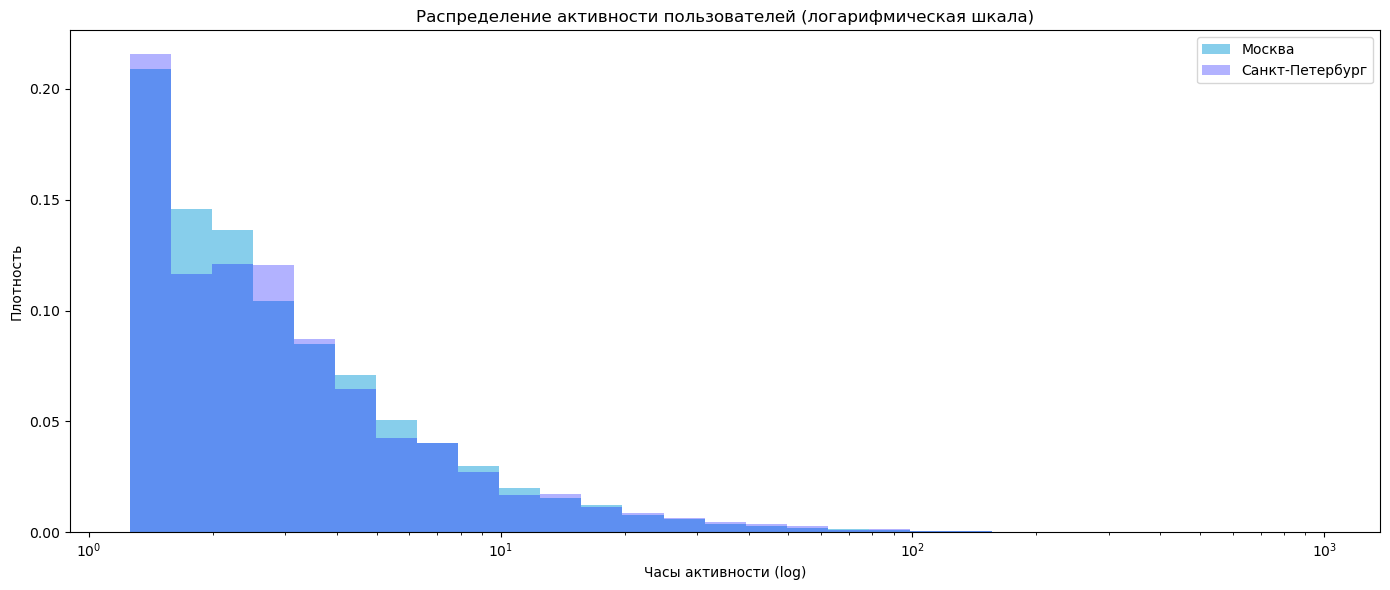

In [14]:
colors = ['skyblue', 'blue']

plt.figure(figsize=(14, 6))

max_val = max(msk_hours.max(), spb_hours.max())
bins = np.logspace(0.1, np.log10(max_val), 30)  # 0.1 чтобы избежать log(0)

plt.hist(msk_hours, bins=bins, color=colors[0], label='Москва', density=True)
plt.hist(spb_hours, bins=bins, alpha=0.3, color=colors[1], label='Санкт-Петербург', density=True)

plt.xscale('log')
plt.title('Распределение активности пользователей (логарифмическая шкала)')
plt.xlabel('Часы активности (log)')
plt.ylabel('Плотность')
plt.legend()
plt.tight_layout()
plt.show()

Распределение активности носит неравномерный характер, с явным доминированием пользователей с малыми часами чтения. Города демонстрируют схожие тенденции, но с небольшими отличиями в доле среднеактивных пользователей.

## 1.6. Проверка гипотезы в Python
Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- <b>Нулевая гипотеза H₀:</b> Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- <b>Альтернативная гипотеза H₁:</b> Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Выше мы нашли, что данные в выборке распределены неодинаково, что исключает в дальнейшем использование t-теста Стьюдента. Следует проверить равенство дисперсий выборок.

In [15]:
disp_users_group=yandex_knigi_data_clear.groupby('city')['hours'].var()

disp_users_group

city
Москва             1358.046537
Санкт-Петербург    1586.568674
Name: hours, dtype: float64

Посмотрим на стандартное отклонение по группам.

In [16]:
std_users_group=yandex_knigi_data_clear.groupby('city')['hours'].std()

std_users_group

city
Москва             36.851683
Санкт-Петербург    39.831755
Name: hours, dtype: float64

Высокий разброс (особенно в СПб) говорит, что пользователи сильно различаются по времени использования (hours). Есть как «активные», так и «редкие» пользователи.
Классический двухвыборочный t-критерий Стьюдента для независимых выборок требует соблюдения условия равенства дисперсий. Поэтому остановимся на тесте Уэлча. 

Разделим на группы для проведения теста Уэлча.

In [17]:
msk_hours=yandex_knigi_data_clear[yandex_knigi_data_clear['city']=='Москва']['hours']
spb_hours=yandex_knigi_data_clear[yandex_knigi_data_clear['city']=='Санкт-Петербург']['hours']

In [18]:
alpha=0.05

t_stat, p_value=ttest_ind(
    spb_hours,           
    msk_hours,        
    equal_var=False,     
    alternative='greater' 
)
print(f'p-value: {p_value:.4f}')

if p_value>alpha:
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группах не различаются.')
else:
    print('Нулевая гипотеза не находит подтверждения! Пользователи Санкт-Петербурга читают больше.')

p-value: 0.3436
Нулевая гипотеза находит подтверждение! Распределения метрики в группах не различаются.


Как альтернативный метод можно рассмотреть тест Манна-Уитни.

In [19]:
alpha=0.05

stat_mw, p_value=mannwhitneyu(
    spb_hours,
    msk_hours,
    alternative='greater'
)

print(f'p-value: {p_value:.4f}')

if p_value<alpha:
 print('Отклоняем нулевую гипотезу! Пользователи Санкт-Петербурга читают больше.')
else:
 print('Не удалось отвергнуть нулевую гипотезу! Распределения метрики в группах не различаются.')

p-value: 0.6190
Не удалось отвергнуть нулевую гипотезу! Распределения метрики в группах не различаются.


Оба теста показали, что не получилось отвергнуть нулевую гипотезу. Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

## 1.7. Аналитическая записка

<b>1. Выбранный тип t‑теста и уровень статистической значимости</b>

Тип t‑теста: t‑критерий Уэлча.
Обоснование: тест не предполагает равенства дисперсий в группах (что реалистично для реальных данных), что делает его более консервативным и надёжным при возможных различиях в вариативности между выборками.

Уровень статистической значимости (α): 0.05.
Это стандартный порог в прикладных исследованиях: если `p‑value`<0.05, нулевая гипотеза отвергается в пользу альтернативной.

Альтернативная гипотеза: «Пользователи Санкт‑Петербурга читают больше, чем пользователи Москвы».

<b>2. Результат теста (`p‑value`)</b>

t‑тест Уэлча: `p‑value`=0.3436.

Тест Манна — Уитни: `p‑value`=0.6190.(альтернативная проверка)

Оба значения существенно превышают порог α=0.05.

<b>3. Вывод на основе `p‑value`</b>

Для t‑теста:
Поскольку `p‑value`=0.3436>0.05, нет оснований отвергнуть нулевую гипотезу. Статистически значимых различий в среднем времени чтения между пользователями Санкт‑Петербурга и Москвы не обнаружено.

Для теста Манна — Уитни:
`p‑value`=0.6190>0.05 также не позволяет отвергнуть нулевую гипотезу. Ранговые распределения времени чтения в двух группах не различаются значимо.

Общий вывод:
Оба теста независимо подтверждают, что различия во времени чтения между пользователями Санкт‑Петербурга и Москвы не являются статистически значимыми при уровне значимости 5%. Данные не дают оснований утверждать, что петербуржцы читают больше москвичей.

<b>4. Возможные причины полученных результатов</b>

Вероятно, географическое расположение (Санкт‑Петербург vs Москва) не влияет на время чтения. 

Малый размер выборки: если группы невелики, тесты могут не обнаружить слабый, но реальный эффект.

Разброс времени чтения внутри каждой группы.





# 2. Анализ результатов A/B-тестирования

## 2.1. Цели и задачи 2 части
Основная цель данной части: определить, действительно ли новая версия сайта для BitMotion Kit достоверно повышает конверсию в покупку (число пользователей, совершивших заказ), и можно ли её внедрять.

Задачи:
- загрузить данные, оценить их целостность;
- проверить корректность проведения теста;
- сделать оценку результатов A/B-тестирования.

Гипотезы:
- <b>Нулевая гипотеза H₀:</b> Новая версия сайта не принесла статистически важных изменений. 

- <b>Альтернативная гипотеза H₁:</b> Новая версия сайта принесла статистически важные изменения.

## 2.2. Описание данных

`ab_test_participants.csv` — таблица участников тестов. Путь к файлу: `/datasets/ab_test_participants.csv`.

Поля таблицы:
- `user_id` — идентификатор пользователя;
- `group` — группа пользователя;
- `ab_test` — название теста;
- `device` — устройство, с которого происходила регистрация.
  
`ab_test_events.zip` — архив с одним `csv`-файлом, в котором собраны события 2020 года. Путь к файлу: `/datasets/ab_test_events.zip`.

Поля файла:
- `user_id` — идентификатор пользователя;
- `event_dt` — дата и время события;
- `event_name` — тип события;
- `details` — дополнительные данные о событии.

Дополнительная информация по столбцу `details`

Числовые значения:
- `registration` (регистрация) — стоимость привлечения клиента;
- `purchase` (покупка) — стоимость покупки.

## 2.3. Загрузка данных

In [20]:
participants=pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events=pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [21]:
participants.info()
participants.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


Пропусков в данных таблицы `participants` нет. Уже видно, что некоторые пользователи участвуют в нескольких тестах сразу.

In [22]:
events.info()
events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


В столбце `details` таблицы `events` из 787286 строк только 249022 не являются пустыми или 31.63% от общего числа. В этом столбце содержится дополнительная информация.  

Типы данных соответствуют в обеих таблицах информации внутри. Сделаем проверку на дубликаты.

In [23]:
duplicates_participants=participants['user_id'].duplicated().sum()

duplicates_participants

np.int64(887)

Одни и те же пользователи присутствуют в обеих группах, ранее уже было отмечено это. Выведем некоторые значения для наглядности. Если это так, то можно будет удалить эти дубликаты.

In [24]:
duplicates_participants=participants[participants.duplicated(subset=['user_id'])]['user_id'].to_list()

participants[participants['user_id'].isin(duplicates_participants)].sort_values(by='user_id').head(8)

,user_id,group,ab_test,device
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
9,00341D8401F0F665,A,recommender_system_test,iPhone
10,00341D8401F0F665,B,interface_eu_test,iPhone
25,0082295A41A867B5,A,interface_eu_test,iPhone
26,0082295A41A867B5,A,recommender_system_test,iPhone
41,00E68F103C66C1F7,A,recommender_system_test,PC
42,00E68F103C66C1F7,A,interface_eu_test,PC


In [25]:
participants_clear=participants.drop_duplicates(subset='user_id', keep='first')

participants_clear.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13638 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  13638 non-null  object
 1   group    13638 non-null  object
 2   ab_test  13638 non-null  object
 3   device   13638 non-null  object
dtypes: object(4)
memory usage: 532.7+ KB


In [26]:
duplicates_events_id=events['user_id'].duplicated().sum()

duplicates_events_id

np.int64(643102)

In [27]:
duplicates_events=events['event_dt'].duplicated().sum()

duplicates_events

np.int64(180713)

In [28]:
duplicates_events_mask=events.duplicated(subset=['user_id', 'event_dt', 'event_name']).sum()

duplicates_events_mask

np.int64(39510)

То есть в каждом столбце таблицы `events` встречаются дубликаты. 

Дубли в `user_id` — норма, так как пользователь может выполнять действия многократно.

Одинаковые значения в `events_dt` возникают из‑за параллельных действий разных пользователей.

В `event_name` и `details` повторы ожидаемы: это метки категорий, а не уникальные идентификаторы.

## 2.4. По таблице `ab_test_participants` оценить корректность проведения теста
### 2.4.1. Пользователи, участвующие в тесте

Необходимо выделить пользователей, участвующих в тесте. Проверить:
- соответствие требованиям технического задания,
- равномерность распределения пользователей по группам теста,
- отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

Отберём данные по названию теста `interface_eu_test`.

In [29]:
ab_test_participants=participants_clear[participants_clear['ab_test']=='interface_eu_test'].reset_index(drop=True)

print(f'Число участников теста: {len(ab_test_participants)}')
ab_test_participants

Число участников теста: 10403


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001E72F50D1C48FA,A,interface_eu_test,Mac
2,002412F1EB3F6E38,B,interface_eu_test,Mac
3,002540BE89C930FB,B,interface_eu_test,Android
4,0031F1B5E9FBF708,A,interface_eu_test,Android
...,...,...,...,...
10398,FFE5B14BD55C1C5C,A,interface_eu_test,PC
10399,FFE600EEC4BA7685,B,interface_eu_test,Android
10400,FFE7FC140521F5F6,A,interface_eu_test,PC
10401,FFEFC0E55C1CCD4F,A,interface_eu_test,PC


Проверим количество пользователей по группам в абсолютном и относительном значениях.

In [30]:
test_group=ab_test_participants['group'].value_counts()
test_group_ratio=ab_test_participants['group'].value_counts(normalize=True)

print(test_group)
print(test_group_ratio)

group
B    5229
A    5174
Name: count, dtype: int64
group
B    0.502643
A    0.497357
Name: proportion, dtype: float64


Посчитаем процентную разницу между группами.

In [31]:
diff_a_b=round(100*abs(test_group['A']-test_group['B'])/test_group['A'],2)

diff_a_b

np.float64(1.06)

Процентная разница между группами составляет 1.06%. Можно сказать, что пользователи равномерно распределены.

Ознакомимся с распределением по устройствам участников теста.

In [32]:
device_group_test=ab_test_participants.groupby(['group','device'])['user_id'].nunique().reset_index()

device_group_test

,group,device,user_id
0,A,Android,2356
1,A,Mac,542
2,A,PC,1286
3,A,iPhone,990
4,B,Android,2320
5,B,Mac,527
6,B,PC,1356
7,B,iPhone,1026


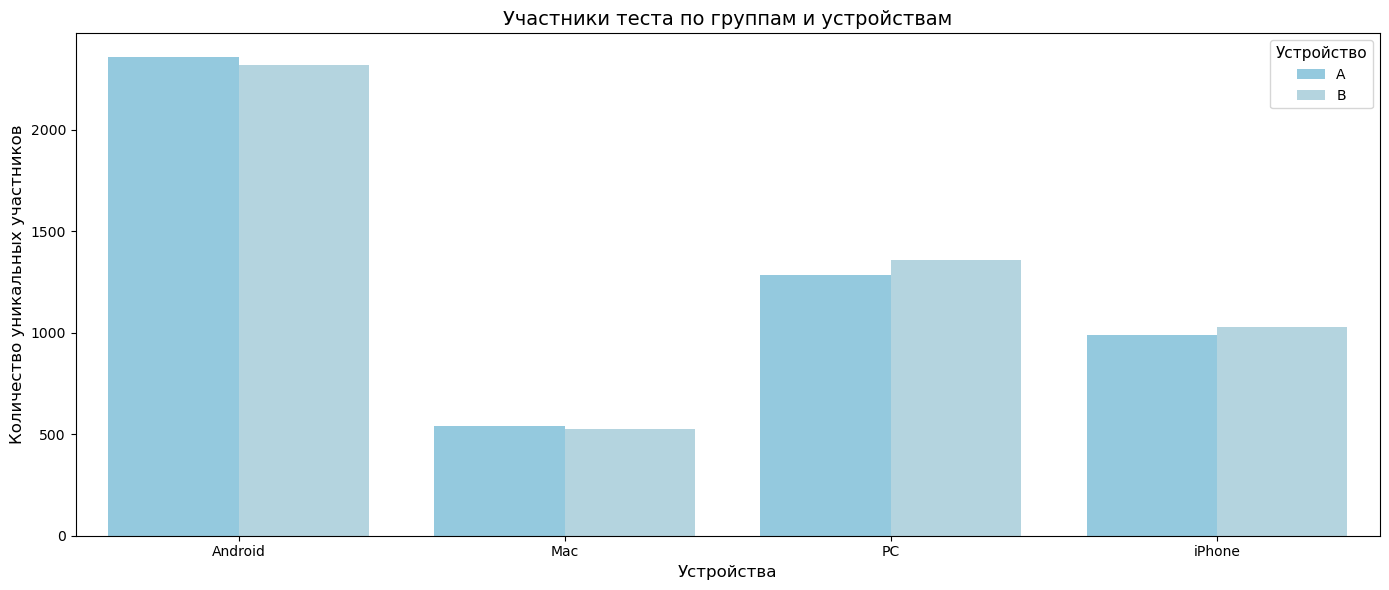

In [33]:
colors = ['skyblue', 'lightblue']

plt.figure(figsize=(14, 6))
sns.barplot(data=device_group_test, x='device', y='user_id', hue='group', palette=colors)
plt.title('Участники теста по группам и устройствам', fontsize=14)
plt.xlabel('Устройства', fontsize=12)
plt.ylabel('Количество уникальных участников', fontsize=12)
plt.legend(title='Устройство', title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.show()

Можно отметить, что и по видам используемых устройств пользователи распределены равномерно.

Дополнительно проверим: есть ли участники теста, которые встречаются в обеих группах.

In [34]:
group_a=set(ab_test_participants[ab_test_participants['group']=='A']['user_id'].unique())
group_b=set(ab_test_participants[ab_test_participants['group']=='B']['user_id'].unique())
group_a_b=group_a.intersection(group_b)

if len(group_a_b)==0:
    print("Нет участников, которые встречаются в обеих группах") 
else:
    print(f"Количество участников в обеих группах: {len(group_a_b)}")

Нет участников, которые встречаются в обеих группах


In [35]:
events['event_dt']=pd.to_datetime(events['event_dt'])
test_events=events[events['user_id'].isin(ab_test_participants['user_id'])]

print(f"\nТест проводился с {test_events['event_dt'].min().date()} по {test_events['event_dt'].max().date()}")


Тест проводился с 2020-12-06 по 2020-12-30


### 2.4.2. Анализ пользовательской активности по таблице `ab_test_events`

Оставим только события, связанные с участвующими в изучаемом тесте пользователями.

In [36]:
ab_test_events=ab_test_participants.merge(events, on='user_id', how='left').reset_index(drop=True)

ab_test_events.info()
ab_test_events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76658 entries, 0 to 76657
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     76658 non-null  object        
 1   group       76658 non-null  object        
 2   ab_test     76658 non-null  object        
 3   device      76658 non-null  object        
 4   event_dt    76658 non-null  datetime64[ns]
 5   event_name  76658 non-null  object        
 6   details     20217 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.1+ MB


,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN


Определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации.

In [37]:
ab_test_events['event_dt']=pd.to_datetime(ab_test_events['event_dt'])  

first_activ=ab_test_events.groupby('user_id')['event_dt'].min().reset_index()
first_activ.rename(columns={'event_dt': 'registration_dt'}, inplace=True)
ab_test_events=ab_test_events.merge(first_activ, on='user_id', how='left')

#Расчет лайфтайма
ab_test_events['lifetime']=(ab_test_events['event_dt']-ab_test_events['registration_dt']).dt.days
ab_test_events_filtered=ab_test_events[ab_test_events['lifetime']<7] #первые 7 дней)

print(f'Исходное количество событий: {len(ab_test_events)}')
print(f'Количество событий после фильтрации (лайфтайм<7 дней): {len(ab_test_events_filtered)}')

ab_test_events_filtered.head(10)

Исходное количество событий: 76658
Количество событий после фильтрации (лайфтайм<7 дней): 66262


,user_id,group,ab_test,device,event_dt,event_name,details,registration_dt,lifetime
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31,0
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN,2020-12-07 04:37:31,0
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN,2020-12-07 04:37:31,0
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN,2020-12-07 04:37:31,0
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN,2020-12-07 04:37:31,1
5,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:36,product_page,NaN,2020-12-07 04:37:31,1
6,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:37,product_page,NaN,2020-12-07 04:37:31,1
7,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-10 15:23:08,product_page,NaN,2020-12-07 04:37:31,3
8,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-10 15:23:09,product_cart,NaN,2020-12-07 04:37:31,3
11,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61,2020-12-17 15:44:05,0


In [38]:
users_7_days=ab_test_events_filtered['user_id'].nunique()

users_7_days

10403

Все участники теста попали в `lifetime`.

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста.

Заданные параметры:
- базовый показатель конверсии — 30%,
- мощность теста — 80%,
- достоверность теста — 95%.

При заданных параметрах рекомендуемая MDE≈3.3–3.7 п.п.

In [39]:
alpha=0.05

power=0.8   
p=0.3       
mde=0.03 

effect_size = proportion_effectsize(p, p + mde)  # p + 0.03

power_analysis = NormalIndPower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  
)

print(f"Необходимый размер выборки для каждой группы: {(sample_size):.0f}")
print(f"Общий необходимый размер выборки: {(2 * sample_size):.0f}")

Необходимый размер выборки для каждой группы: 3762
Общий необходимый размер выборки: 7523


Количество уникальных участников в финальной выборке теста равняется 10403.
Условие выполнено.

Рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [40]:
buyer_users=ab_test_events_filtered.loc[(ab_test_events_filtered['event_name']=='purchase')]

n_a=ab_test_events_filtered.loc[(ab_test_events_filtered['group']=='A')]['user_id'].nunique()
n_b=ab_test_events_filtered.loc[(ab_test_events_filtered['group']=='B')]['user_id'].nunique()
print(f'Количество уникальных участников для групп А и В:{n_a, n_b}')

m_a=buyer_users.loc[(buyer_users['group']=='A')]['user_id'].nunique()
m_b=buyer_users.loc[(buyer_users['group']=='B')]['user_id'].nunique()
print(f'Количество уникальных участников, совершивших покупку для групп А и В:{m_a, m_b}')

p_a, p_b=m_a/n_a, m_b/n_b
print(f'Доля участников, совершивших покупку для групп А и В:{p_a: .5f}, {p_b:.5f}')

conversion_percent=(p_b-p_a)*100
print(f'Увеличение конверсии в группе В по сравнению с группой А:{conversion_percent: .3f} п.п.')

relative_conversion_percent=((p_b-p_a)/p_b)*100
print(f'Относительное увеличение конверсии в группе В по сравнению с группой А:{relative_conversion_percent: .2f} %')

Количество уникальных участников для групп А и В:(5174, 5229)
Количество уникальных участников, совершивших покупку для групп А и В:(1427, 1532)
Доля участников, совершивших покупку для групп А и В: 0.27580, 0.29298
Увеличение конверсии в группе В по сравнению с группой А: 1.718 п.п.
Относительное увеличение конверсии в группе В по сравнению с группой А: 5.86 %


На текущем этапе нет оснований для внедрения нового интерфейса, так как:
- заявленный минимальный эффект (+3 п.п.) не достигнут;
- статистическая значимость разницы пока не подтверждена.

## 2.5. Оценка результатов A/B-тестирования
Сделаем проверку предпосылки для Z-теста (np>10 и n(1-p)>10)

In [41]:
if (n_a*p_a>10) and (n_a*(1-p_a)>10) and (n_b*p_b>10) and (n_b*(1-p_b)>10):
    print("Предпосылка для Z-теста выполняется.")
else:
    print("Предпосылка для Z-теста НЕ выполняется — результаты могут быть неточными.")

Предпосылка для Z-теста выполняется.


In [42]:
alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative='larger'
)

if p_value_ztest>alpha:
    print(f'pvalue={p_value_ztest:.5f}>{alpha}')
    print('Наблюдаемое изменение в метрики долей НЕ является статистически значимым')
else:
    print(f'pvalue={p_value_ztest:.5f}<{alpha}')
    print('Наблюдаемое изменение в метрики долей является статистически значимым')

pvalue=0.02607<0.05
Наблюдаемое изменение в метрики долей является статистически значимым


<b>Отклонение нулевой гипотезы</b>

Нулевая гипотеза H₀ (Новая версия сайта не принесла статистически важных изменений) отвергнута.
Это означает: наблюдаемый рост конверсии не случаен и с высокой вероятностью обусловлен внесёнными изменениями.

Альтернативная гипотеза H₁: Новая версия сайта принесла статистически важные изменения.

<b>Сравнение с целевым эффектом</b>

- Ожидаемый эффект: +3 п.п. (целевой ориентир).
- Фактический эффект: <span style="color: red;">+1.718 п.п.</span> (подтверждён статистически).

Вывод: улучшение есть, но оно не достигло запланированного уровня.

<b>Надежность выводов обеспечена</b>

- достаточный размерй выборки (<span style="color: red;">10403</span> пользователей) — это снижает риск ошибок из‑за случайной флуктуации.

- высокая статистическая мощность — тест способен обнаруживать реальные эффекты.

- однородность групп — исключены систематические искажения (например, перекосы в распределении аудитории).

<b>Положительный аспект:</b> новая версия сайта действительно работает лучше старой (рост конверсии статистически значим).

<b>Ограничение:</b> эффект меньше ожидаемого. Если цель строго привязана к +3 п.п. — требуется доработка и повторный тест.